In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import igraph as ig
import pickle
import itertools
import timeit
import datetime

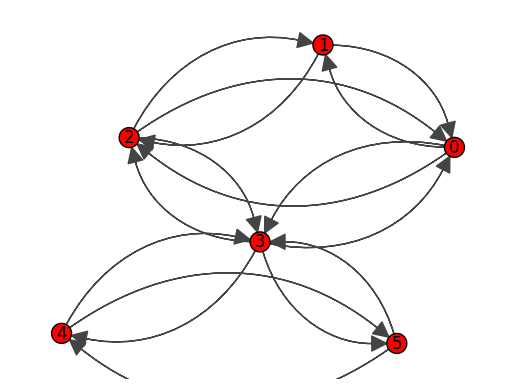

In [166]:
g = ig.Graph(directed=True)
g.add_vertices(6)
g.add_edges([(0, 1), (0, 2), (1, 2), (1, 0), (2, 0), (2, 1), (3, 4), (4, 3), (4, 5), (5, 4), (5, 3), (3, 5), (2, 3), (3, 2), (3, 0), (0, 3)])

# Plot the graph
fig, ax = plt.subplots()
ig.plot(
    g,
    target=ax,
    vertex_label=range(g.vcount()),
    vertex_size=20,
    edge_width=1
)
plt.show()

In [167]:
tc = g.triad_census()

tc

TriadCensus((0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 3))

In [168]:
nodes = g.vs.indices

edges = g.get_edgelist()
edges_set = set(edges)

In [169]:
ba_bc = [] #021D
ab_cb = [] #021U
ab_bc = [] #021C
ab_ba_cb = [] #111D
ab_bc_ba = [] #111U
ab_cb_ac = [] #030T
ba_cb_ac = [] #030C
ab_ba_ac_ca = [] #201
ba_bc_ca_ac = [] #120D
ab_cb_ac_ca = [] #120U
ab_bc_ca_ac = [] #120C
ab_bc_cb_ca_ac = [] #210
ab_ba_ac_ca_bc_cb = [] #300

for a in nodes:
    
    neighbor_vertices_a = g.vs[g.neighbors(a, mode="all")]
    neighbor_ids_a = [vertex.index for vertex in neighbor_vertices_a]
    
    for b in neighbor_ids_a:
        print('vicini di ' + str(a) + str(union_neighbor_ab))
        
        neighbor_vertices_b = g.vs[g.neighbors(b, mode="all")]
        neighbor_ids_b = [vertex.index for vertex in neighbor_vertices_b]
        
        union_neighbor_ab = list(set().union(neighbor_ids_a, neighbor_ids_b))
        union_neighbor_ab.remove(a)
        union_neighbor_ab.remove(b)

        #print('vicini di ' + str(a) + ' e ' + str(b) + str(union_neighbor_ab))
        
        
        for c in union_neighbor_ab:

            # 021D ba_bc
            if (b, a) in edges_set and (b, c) in edges_set and (a, b) not in edges_set and (a, c) not in edges_set and (c, b) not in edges_set and (b, a) not in edges_set:
                if (a, b) not in edges_set and (c, b) not in edges_set:
                    ba_bc.append((a, b, c))

            # 021U ab_cb
            if (a, b) in edges_set and (c, b) in edges_set and (b, a) not in edges_set and (b, c) not in edges_set and (a, c) not in edges_set and (c, a) not in edges_set:
                    ab_cb.append((a, b, c))

            # 021C ab_bc
            if (a, b) in edges_set and (b, c) in edges_set and (b, a) not in edges_set and (c, b) not in edges_set and (a, c) not in edges_set and (c, a) not in edges_set:
                ab_bc.append((a, b, c))

            # 111D ab_ba_cb
            if (a, b) in edges_set and (b, a) in edges_set and (c, b) in edges_set and (b, c) not in edges_set and (a, c) not in edges_set and (c, a) not in edges_set:
                ab_ba_cb.append((a, b, c))

            # 111U ab_bc_ba
            if (a, b) in edges_set and (b, c) in edges_set and (b, a) in edges_set and (c, b) not in edges_set and (a, c) not in edges_set and (c, a) not in edges_set:
                ab_bc_ba.append((a, b, c))

            # 030T ab_cb_ac
            if (a, b) in edges_set and (c, b) in edges_set and (a, c) in edges_set and (b, a) not in edges_set and (b, c) not in edges_set and (c, a) not in edges_set:
                ab_cb_ac.append((a, b, c))

            # 030C ba_cb_ac
            if (b, a) in edges_set and (c, b) in edges_set and (a, c) in edges_set and (a, b) not in edges_set and (b, c) not in edges_set and (c, a) not in edges_set:
                ba_cb_ac.append((a, b, c))

            # 201 ab_ba_ac_ca
            if (a, b) in edges_set and (b, a) in edges_set and (a, c) in edges_set and (c, a) in edges_set and (b, c) not in edges_set and (c, b) not in edges_set:
                ab_ba_ac_ca.append((a, b, c))

            # 120D ba_bc_ca_ac
            if (b, a) in edges_set and (b, c) in edges_set and (c, a) in edges_set and (a, c) in edges_set and (a, b) not in edges_set and (c, b) not in edges_set:
                ba_bc_ca_ac.append((a, b, c))

            # 120U ab_cb_ac_ca
            if (a, b) in edges_set and (c, b) in edges_set and (a, c) in edges_set and (c, a) in edges_set and (b, a) not in edges_set and (b, c) not in edges_set:
                ab_cb_ac_ca.append((a, b, c))

            # 120C ab_bc_ca_ac
            if (a, b) in edges_set and (b, c) in edges_set and (c, a) in edges_set and (a, c) in edges_set and (b, a) not in edges_set and (c, b) not in edges_set:
                ab_bc_ca_ac.append((a, b, c))

            # 210 ab_bc_cb_ca_ac
            if (a, b) in edges_set and (b, c) in edges_set and (c, b) in edges_set and (c, a) in edges_set and (a, c) in edges_set and (b, a) not in edges_set:
                ab_bc_cb_ca_ac.append((a, b, c))

            # 300 ab_ba_ac_ca_bc_cb
            if (a, b) in edges_set and (b, a) in edges_set and (a, c) in edges_set and (c, a) in edges_set and (b, c) in edges_set and (c, b) in edges_set:
                ab_ba_ac_ca_bc_cb.append((a, b, c))


vicini di 0[3]
vicini di 0[2, 3]
vicini di 0[2, 3]
vicini di 0[1, 3]
vicini di 0[1, 3]
vicini di 0[1, 2, 4, 5]
vicini di 1[1, 2, 4, 5]
vicini di 1[2, 3]
vicini di 1[2, 3]
vicini di 1[0, 3]
vicini di 2[0, 3]
vicini di 2[1, 3]
vicini di 2[1, 3]
vicini di 2[0, 3]
vicini di 2[0, 3]
vicini di 2[0, 1, 4, 5]
vicini di 3[0, 1, 4, 5]
vicini di 3[1, 2, 4, 5]
vicini di 3[1, 2, 4, 5]
vicini di 3[0, 1, 4, 5]
vicini di 3[0, 1, 4, 5]
vicini di 3[0, 2, 5]
vicini di 3[0, 2, 5]
vicini di 3[0, 2, 4]
vicini di 4[0, 2, 4]
vicini di 4[0, 2, 5]
vicini di 4[0, 2, 5]
vicini di 4[3]
vicini di 5[3]
vicini di 5[0, 2, 4]
vicini di 5[0, 2, 4]
vicini di 5[3]


In [170]:
print('igraph: ' + str(tc.t021d) + ' nostro: ' + str(len(set(ba_bc)))) #021D
print('igraph: ' + str(tc.t021u) + ' nostro: ' + str(len(set(ab_cb)))) #021U
print('igraph: ' + str(tc.t021c) + ' nostro: ' + str(len(set(ab_bc)))) #021C
print('igraph: ' + str(tc.t111d) + ' nostro: ' + str(len(set(ab_ba_cb)))) #111D
print('igraph: ' + str(tc.t111u) + ' nostro: ' + str(len(set(ab_bc_ba)))) #111U
print('igraph: ' + str(tc.t030t) + ' nostro: ' + str(len(set(ab_cb_ac)))) #030T
print('igraph: ' + str(tc.t030c) + ' nostro: ' + str(len(set(ba_cb_ac)))) #030C
print('igraph: ' + str(tc.t201) + ' nostro: ' + str(len(set(ab_ba_ac_ca)))) #201
print('igraph: ' + str(tc.t120d) + ' nostro: ' + str(len(set(ba_bc_ca_ac)))) #120D
print('igraph: ' + str(tc.t120c) + ' nostro: ' + str(len(set(ab_bc_ca_ac)))) #120C
print('igraph: ' + str(tc.t210) + ' nostro: ' + str(len(set(ab_bc_cb_ca_ac)))) #210
print('igraph: ' + str(tc.t300) + ' nostro: ' + str(len(set(ab_ba_ac_ca_bc_cb)))) #300

igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 6 nostro: 12
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 0 nostro: 0
igraph: 3 nostro: 18


In [171]:
edges_set

{(0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 2),
 (2, 0),
 (2, 1),
 (2, 3),
 (3, 0),
 (3, 2),
 (3, 4),
 (3, 5),
 (4, 3),
 (4, 5),
 (5, 3),
 (5, 4)}

In [172]:
def remove_duplicate_tuples(tuples_list):
    unique_tuples_set = set()

    for tpl in tuples_list:
        sorted_tpl = tuple(sorted(tpl))
        unique_tuples_set.add(sorted_tpl)

    # Convert the set back to a list of tuples if needed
    unique_tuples_list = list(unique_tuples_set)
    return unique_tuples_list

In [173]:
print('021D igraph: ' + str(tc.t021d) + ' nostro: ' + str(len(remove_duplicate_tuples(ba_bc)))) #021D
print('021U igraph: ' + str(tc.t021u) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_cb)))) #021U
print('021C igraph: ' + str(tc.t021c) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_bc)))) #021C
print('111D igraph: ' + str(tc.t111d) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_ba_cb)))) #111D
print('111U igraph: ' + str(tc.t111u) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_bc_ba)))) #111U
print('030T igraph: ' + str(tc.t030t) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_cb_ac)))) #030T
print('030C igraph: ' + str(tc.t030c) + ' nostro: ' + str(len(remove_duplicate_tuples(ba_cb_ac)))) #030C
print('201 igraph: ' + str(tc.t201) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_ba_ac_ca)))) #201
print('120D igraph: ' + str(tc.t120d) + ' nostro: ' + str(len(remove_duplicate_tuples(ba_bc_ca_ac)))) #120D
print('120C igraph: ' + str(tc.t120c) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_bc_ca_ac)))) #120C
print('210 igraph: ' + str(tc.t210) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_bc_cb_ca_ac)))) #210
print('300 igraph: ' + str(tc.t300) + ' nostro: ' + str(len(remove_duplicate_tuples(ab_ba_ac_ca_bc_cb)))) #300

021D igraph: 0 nostro: 0
021U igraph: 0 nostro: 0
021C igraph: 0 nostro: 0
111D igraph: 0 nostro: 0
111U igraph: 0 nostro: 0
030T igraph: 0 nostro: 0
030C igraph: 0 nostro: 0
201 igraph: 6 nostro: 6
120D igraph: 0 nostro: 0
120C igraph: 0 nostro: 0
210 igraph: 0 nostro: 0
300 igraph: 3 nostro: 3
